In [1]:
import os
import numpy as np
import pandas as pd

df = pd.read_csv("extracted_flares.csv")
print(f"Dataset compiled. Total row count: {len(df)}")

Dataset compiled. Total row count: 154


In [2]:
partially_convective = ["M2V", "M2.5V", "M3V", "M3.5V"]
fully_convective = ["M4V", "M4.5V", "M5V", "M5.5V", "M6V"]

df_part = df[df["spectral_type"].isin(partially_convective)]
df_full = df[df["spectral_type"].isin(fully_convective)]

print("=== COHORT DISTRIBUTION ===")
print(f"Partially Convective Flares (N): {len(df_part)}")
print(f"Fully Convective Flares (N):    {len(df_full)}")

=== COHORT DISTRIBUTION ===
Partially Convective Flares (N): 76
Fully Convective Flares (N):    78


In [4]:
from scipy.stats import ks_2samp, anderson_ksamp

if len(df_part) < 5 or len(df_full) < 5:
    print("Execution Blocked: Insufficient sample sizes for robust cross-testing.")
else:
    # 1. Kolmogorov-Smirnov Test
    ks_stat, ks_p = ks_2samp(df_part["ratio"], df_full["ratio"])
    
    # 2. Anderson-Darling Test (Examines distribution tails and shapes deeply)
    ad_result = anderson_ksamp([df_part["ratio"].values, df_full["ratio"].values])
    
    print("=== MULTI-PARAMETRIC HYPOTHESIS TESTING ===")
    print(f"K-S Test Statistic:    {ks_stat:.4f} (p = {ks_p:.4e})")
    print(f"Anderson-Darling Stat: {ad_result.statistic:.4f} (Significance Level: {ad_result.pvalue:.4e})")

=== MULTI-PARAMETRIC HYPOTHESIS TESTING ===
K-S Test Statistic:    0.3657 (p = 3.7125e-05)
Anderson-Darling Stat: 12.0205 (Significance Level: 1.0000e-03)


/var/folders/18/bbc7q36j221813sqp8lt6qhc0000gn/T/ipykernel_41383/3903282064.py:10: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = anderson_ksamp([df_part["ratio"].values, df_full["ratio"].values])


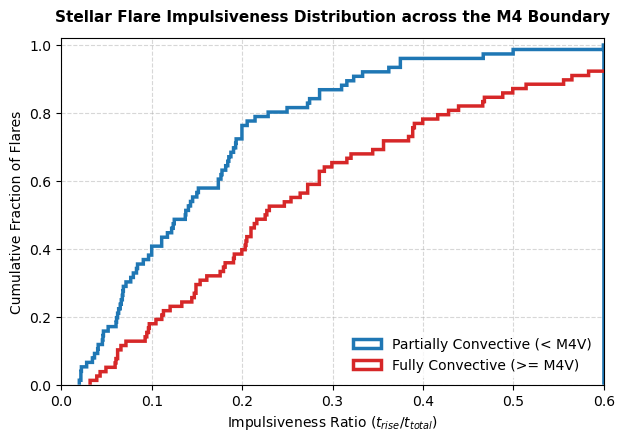

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))

plt.hist(df_part["ratio"], bins=1000, density=True, histtype="step", cumulative=True, 
         label="Partially Convective (< M4V)", color="#1f77b4", linewidth=2.5)
plt.hist(df_full["ratio"], bins=1000, density=True, histtype="step", cumulative=True, 
         label="Fully Convective (>= M4V)", color="#d62728", linewidth=2.5)

plt.title("Stellar Flare Impulsiveness Distribution across the M4 Boundary", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Impulsiveness Ratio ($t_{rise} / t_{total}$)", fontsize=10)
plt.ylabel("Cumulative Fraction of Flares", fontsize=10)
plt.xlim(0.0, 0.6)
plt.ylim(0.0, 1.02)
plt.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig("flare_convective_cdf.pdf", bbox_inches="tight", dpi=300)
plt.show()

=== SYSTEMATIC SCALING INSIGHT ===
Spearman's rank correlation (rho): 0.3250
Spearman p-value:                  3.9096e-05


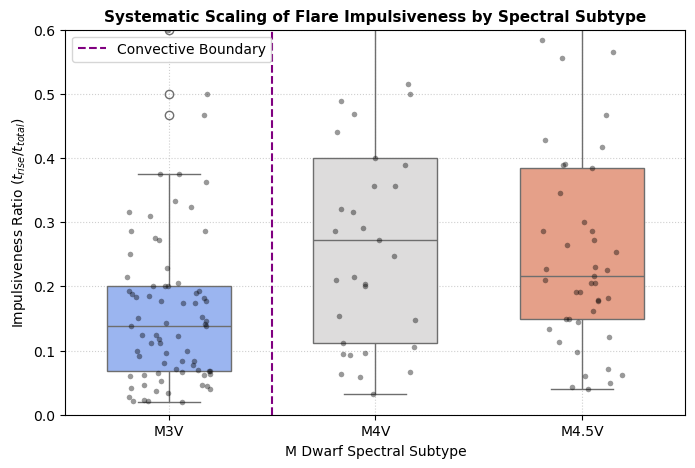

In [6]:
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

spt_mapping = {
    "M2V": 2.0, "M2.5V": 2.5, "M3V": 3.0, "M3.5V": 3.5,
    "M4V": 4.0, "M4.5V": 4.5, "M5V": 5.0, "M5.5V": 5.5, "M6V": 6.0
}
df["spt_numeric"] = df["spectral_type"].map(spt_mapping)

rho, p_val_spearman = spearmanr(df["spt_numeric"], df["ratio"])

print("=== SYSTEMATIC SCALING INSIGHT ===")
print(f"Spearman's rank correlation (rho): {rho:.4f}")
print(f"Spearman p-value:                  {p_val_spearman:.4e}")

plt.figure(figsize=(8, 5))
spt_order = ["M2V", "M2.5V", "M3V", "M3.5V", "M4V", "M4.5V", "M5V", "M6V"]
existing_order = [s for s in spt_order if s in df["spectral_type"].unique()]

sns.boxplot(
    data=df, x="spectral_type", y="ratio", order=existing_order,
    palette="coolwarm", hue="spectral_type", legend=False, width=0.6
)
sns.stripplot(
    data=df, x="spectral_type", y="ratio", order=existing_order,
    color="black", alpha=0.4, size=4, jitter=0.2
)

boundary_idx = existing_order.index("M4V") - 0.5 if "M4V" in existing_order else 3.5
plt.axvline(x=boundary_idx, color="purple", linestyle="--", linewidth=1.5, label="Convective Boundary")
plt.title("Systematic Scaling of Flare Impulsiveness by Spectral Subtype", fontsize=11, fontweight="bold")
plt.xlabel("M Dwarf Spectral Subtype", fontsize=10)
plt.ylabel("Impulsiveness Ratio ($t_{rise} / t_{total}$)", fontsize=10)
plt.ylim(0.0, 0.6)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")

plt.savefig("flare_systematic_scaling.pdf", bbox_inches="tight", dpi=300)
plt.show()